# 03 - Análise de Fluxos (Captação/Resgate)

Análise de movimentações (captação e resgate) dos fundos REAG para identificar padrões suspeitos.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src.processors.data_processor import DataProcessor
from src.analyzers.anomaly_detector import AnomalyDetector
from config.settings import Config

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

## Carregar Lista de Fundos REAG

In [2]:
config = Config()
processor = DataProcessor(config)
detector = AnomalyDetector(config)

# Carregar lista de fundos REAG
reag_list_path = config.PROCESSED_DATA_DIR / 'reag_fund_list.csv'

if reag_list_path.exists():
    df_reag_list = pd.read_csv(reag_list_path)
    reag_cnpjs = df_reag_list['CNPJ_FUNDO'].tolist()
    print(f"✅ {len(reag_cnpjs)} fundos REAG carregados")
else:
    print("⚠️ Execute primeiro o notebook 02_identify_reag_funds.ipynb")
    reag_cnpjs = []

✅ 231 fundos REAG carregados


## Carregar e Consolidar Informe Diário

In [3]:
# Ler todos os arquivos de Informe Diário
# CVM files are named: inf_diario_fi_YYYYMM.csv
informe_files = sorted(config.RAW_DATA_DIR.glob('inf_diario_fi_*.csv'))

# Also check in informe subdirectory if it exists
informe_dir = config.RAW_DATA_DIR / 'informe'
if informe_dir.exists():
    informe_files.extend(list(informe_dir.glob('inf_diario_fi_*.csv')))

informe_files = sorted(set(informe_files))

print(f"📂 Encontrados {len(informe_files)} arquivos de Informe Diário")

if not informe_files:
    print("⚠️ Nenhum arquivo de Informe Diário encontrado")
    print(f"   Procurado em: {config.RAW_DATA_DIR}")
    print(f"   Padrão: inf_diario_fi_*.csv")
    print("\n💡 Execute o notebook 01_data_collection.ipynb para baixar os dados")
    df_informe = pd.DataFrame()
else:
    dfs = []
    for file in informe_files:
        print(f"  Lendo {file.name}...")
        df = processor.read_informe_diario(file)
        dfs.append(df)

    df_informe = pd.concat(dfs, ignore_index=True)
    print(f"\n📊 Total de registros: {len(df_informe):,}")

📂 Encontrados 24 arquivos de Informe Diário
  Lendo inf_diario_fi_202401.csv...
  Lendo inf_diario_fi_202402.csv...
  Lendo inf_diario_fi_202403.csv...
  Lendo inf_diario_fi_202404.csv...
  Lendo inf_diario_fi_202405.csv...
  Lendo inf_diario_fi_202406.csv...
  Lendo inf_diario_fi_202407.csv...
  Lendo inf_diario_fi_202408.csv...
  Lendo inf_diario_fi_202409.csv...
  Lendo inf_diario_fi_202410.csv...


/Users/pedrotodescan/Documents/code/REAG/notebooks/../src/processors/data_processor.py:66: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding=encoding, sep=sep)


  Lendo inf_diario_fi_202411.csv...


/Users/pedrotodescan/Documents/code/REAG/notebooks/../src/processors/data_processor.py:66: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding=encoding, sep=sep)


  Lendo inf_diario_fi_202412.csv...


...

  Lendo inf_diario_fi_202502.csv...


/Users/pedrotodescan/Documents/code/REAG/notebooks/../src/processors/data_processor.py:66: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding=encoding, sep=sep)


  Lendo inf_diario_fi_202503.csv...


/Users/pedrotodescan/Documents/code/REAG/notebooks/../src/processors/data_processor.py:66: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding=encoding, sep=sep)


  Lendo inf_diario_fi_202504.csv...
  Lendo inf_diario_fi_202505.csv...
  Lendo inf_diario_fi_202506.csv...
  Lendo inf_diario_fi_202507.csv...
  Lendo inf_diario_fi_202508.csv...
  Lendo inf_diario_fi_202509.csv...
  Lendo inf_diario_fi_202510.csv...
  Lendo inf_diario_fi_202511.csv...
  Lendo inf_diario_fi_202512.csv...

📊 Total de registros: 12,906,253


## Filtrar Fundos REAG

In [4]:
df_reag = processor.filter_by_cnpj(df_informe, reag_cnpjs)
print(f"📊 Registros de fundos REAG: {len(df_reag):,}")

# Calcular fluxo líquido
df_reag = processor.calculate_net_flow(df_reag)

# Ordenar por data
df_reag = df_reag.sort_values(['CNPJ_FUNDO', 'DT_COMPTC'])

📊 Registros de fundos REAG: 6,225


## Estatísticas Descritivas

In [5]:
print("\n📊 ESTATÍSTICAS DE FLUXO\n" + "="*60)

# Agregado total
total_captacao = df_reag['CAPTC_DIA'].sum()
total_resgate = df_reag['RESG_DIA'].sum()
fluxo_liquido_total = df_reag['FLUXO_LIQ_DIA'].sum()

print(f"Captação total: R$ {total_captacao:,.2f}")
print(f"Resgate total: R$ {total_resgate:,.2f}")
print(f"Fluxo líquido total: R$ {fluxo_liquido_total:,.2f}")

print("\n📈 Estatísticas descritivas:")
display(df_reag[['CAPTC_DIA', 'RESG_DIA', 'FLUXO_LIQ_DIA', 'VL_PATRIM_LIQ']].describe())


📊 ESTATÍSTICAS DE FLUXO
Captação total: R$ 8,259,765,014.80
Resgate total: R$ 15,743,381,883.63
Fluxo líquido total: R$ -7,483,616,868.83

📈 Estatísticas descritivas:


,CAPTC_DIA,RESG_DIA,FLUXO_LIQ_DIA,VL_PATRIM_LIQ
count,6.225000e+03,6.225000e+03,6.225000e+03,6.225000e+03
mean,1.326870e+06,2.529057e+06,-1.202187e+06,7.723428e+08
std,2.101130e+07,1.143141e+07,2.400503e+07,2.306758e+09
min,0.000000e+00,0.000000e+00,-4.443601e+08,-5.749719e+07
25%,0.000000e+00,0.000000e+00,0.000000e+00,3.634937e+06
50%,0.000000e+00,0.000000e+00,0.000000e+00,2.949684e+07
75%,0.000000e+00,0.000000e+00,0.000000e+00,1.648358e+08
max,1.013000e+09,4.447601e+08,1.013000e+09,1.644276e+10


## Evolução Temporal do Fluxo

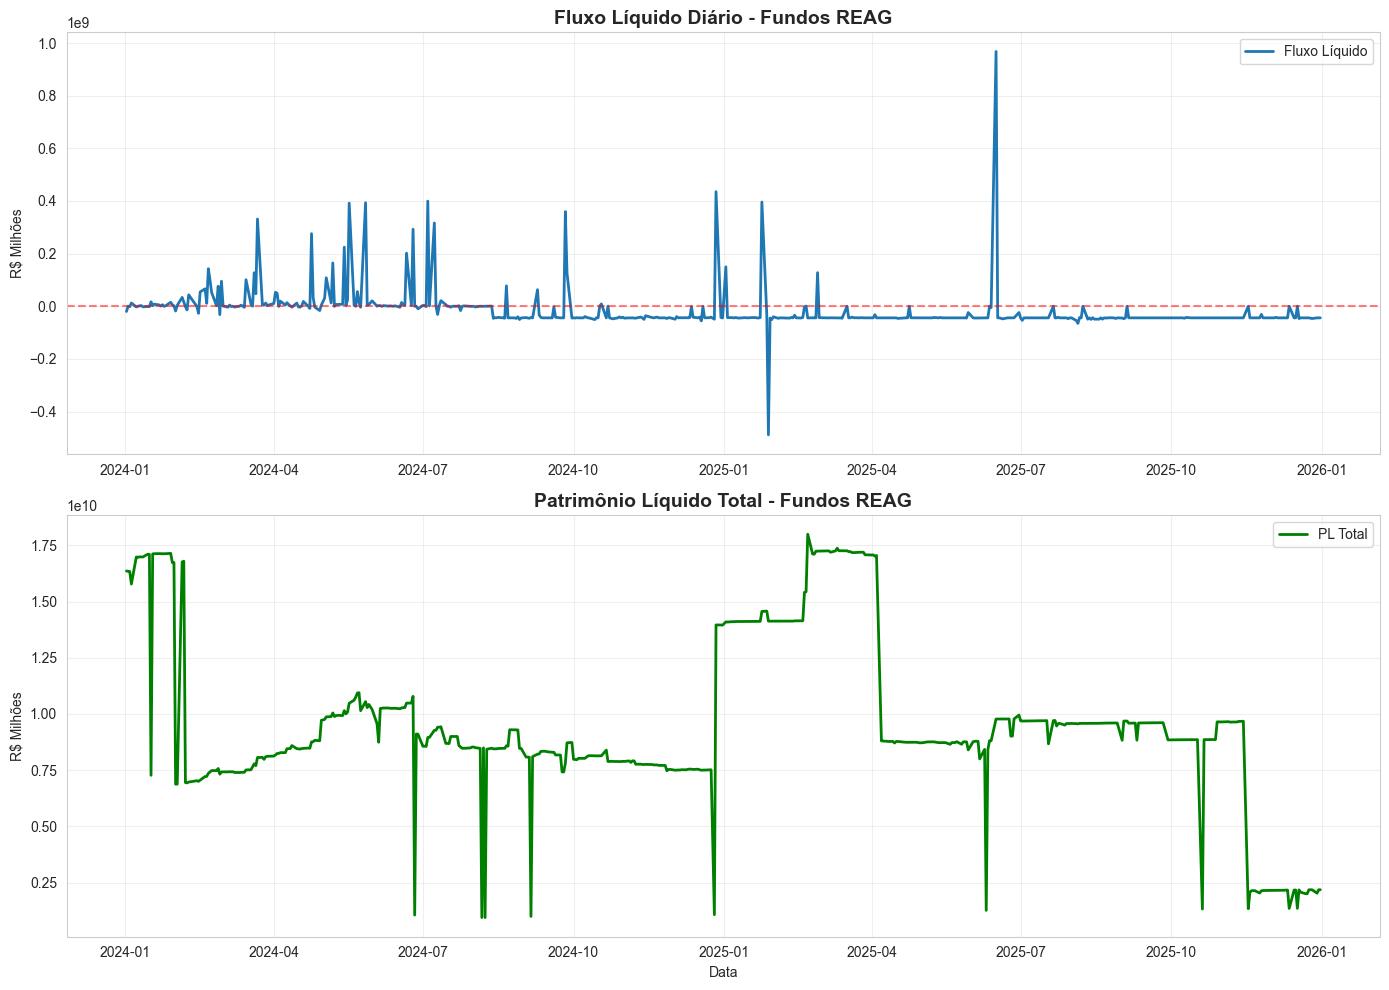

In [6]:
# Agregar por data
df_daily = df_reag.groupby('DT_COMPTC').agg({
    'CAPTC_DIA': 'sum',
    'RESG_DIA': 'sum',
    'FLUXO_LIQ_DIA': 'sum',
    'VL_PATRIM_LIQ': 'sum'
}).reset_index()

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Fluxo líquido
axes[0].plot(df_daily['DT_COMPTC'], df_daily['FLUXO_LIQ_DIA'], label='Fluxo Líquido', linewidth=2)
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Fluxo Líquido Diário - Fundos REAG', fontsize=14, fontweight='bold')
axes[0].set_ylabel('R$ Milhões')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PL agregado
axes[1].plot(df_daily['DT_COMPTC'], df_daily['VL_PATRIM_LIQ'], label='PL Total', linewidth=2, color='green')
axes[1].set_title('Patrimônio Líquido Total - Fundos REAG', fontsize=14, fontweight='bold')
axes[1].set_ylabel('R$ Milhões')
axes[1].set_xlabel('Data')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Top Fundos por Volume de Movimentação

In [7]:
# Agregado por fundo
df_by_fund = df_reag.groupby('CNPJ_FUNDO').agg({
    'CAPTC_DIA': 'sum',
    'RESG_DIA': 'sum',
    'FLUXO_LIQ_DIA': 'sum',
    'VL_PATRIM_LIQ': 'last'
}).reset_index()

df_by_fund['VOLUME_TOTAL'] = df_by_fund['CAPTC_DIA'] + df_by_fund['RESG_DIA']

# Top 10 por volume
top_funds = df_by_fund.nlargest(10, 'VOLUME_TOTAL')

print("\n🏆 TOP 10 FUNDOS POR VOLUME DE MOVIMENTAÇÃO\n" + "="*60)
display(top_funds)


🏆 TOP 10 FUNDOS POR VOLUME DE MOVIMENTAÇÃO


,CNPJ_FUNDO,CAPTC_DIA,RESG_DIA,FLUXO_LIQ_DIA,VL_PATRIM_LIQ,VOLUME_TOTAL
11,41.751.844/0001-51,1.320000e+07,1.456783e+10,-1.455463e+10,0.000000e+00,1.458103e+10
7,36.886.028/0001-15,5.162581e+09,5.613100e+07,5.106450e+09,7.542496e+09,5.218712e+09
4,32.313.878/0001-73,1.790123e+09,1.094669e+09,6.954533e+08,1.032741e+08,2.884792e+09
14,45.616.130/0001-91,1.013000e+09,0.000000e+00,1.013000e+09,1.097805e+09,1.013000e+09
8,36.896.886/0001-40,2.096874e+08,0.000000e+00,2.096874e+08,1.616937e+08,2.096874e+08
9,36.935.858/0001-95,2.016122e+07,1.480709e+05,2.001315e+07,2.118880e+07,2.030929e+07
18,48.963.233/0001-16,1.746149e+07,0.000000e+00,1.746149e+07,4.226563e+07,1.746149e+07
15,46.879.122/0001-09,1.300000e+07,0.000000e+00,1.300000e+07,1.415673e+07,1.300000e+07
0,21.596.695/0001-96,0.000000e+00,1.273100e+07,-1.273100e+07,0.000000e+00,1.273100e+07
5,33.521.273/0001-30,1.000000e+07,0.000000e+00,1.000000e+07,8.223390e+08,1.000000e+07


## Salvar Dados Processados

In [8]:
# Salvar dados REAG processados
output_path = processor.save_processed(df_reag, 'reag_informe_diario_processed.csv')
print(f"\n✅ Dados salvos em: {output_path}")

# Salvar agregados
output_by_fund = processor.save_processed(df_by_fund, 'reag_summary_by_fund.csv')
print(f"✅ Resumo por fundo salvo em: {output_by_fund}")

Dados salvos em: /Users/pedrotodescan/Documents/code/REAG/notebooks/../data/processed/reag_informe_diario_processed.csv

✅ Dados salvos em: /Users/pedrotodescan/Documents/code/REAG/notebooks/../data/processed/reag_informe_diario_processed.csv
Dados salvos em: /Users/pedrotodescan/Documents/code/REAG/notebooks/../data/processed/reag_summary_by_fund.csv
✅ Resumo por fundo salvo em: /Users/pedrotodescan/Documents/code/REAG/notebooks/../data/processed/reag_summary_by_fund.csv


## Resumo

In [9]:
print("\n" + "="*60)
print("📊 RESUMO DA ANÁLISE DE FLUXOS")
print("="*60)
print(f"Fundos analisados: {df_reag['CNPJ_FUNDO'].nunique()}")
print(f"Período: {df_reag['DT_COMPTC'].min()} a {df_reag['DT_COMPTC'].max()}")
print(f"Captação total: R$ {total_captacao:,.2f}")
print(f"Resgate total: R$ {total_resgate:,.2f}")
print(f"Fluxo líquido: R$ {fluxo_liquido_total:,.2f}")
print("\n✅ Análise concluída! Próximo passo: 04_anomaly_detection.ipynb")


📊 RESUMO DA ANÁLISE DE FLUXOS
Fundos analisados: 22
Período: 2024-01-02 00:00:00 a 2025-12-31 00:00:00
Captação total: R$ 8,259,765,014.80
Resgate total: R$ 15,743,381,883.63
Fluxo líquido: R$ -7,483,616,868.83

✅ Análise concluída! Próximo passo: 04_anomaly_detection.ipynb
